# Land-use demand model — lab

Land use replaces density. A block is a mix of residential / commercial / industrial
plots; the mix sets both the demand **level** (plot-intensity table, dialled by `beta`)
and the demand **shape** (per-sector daily and weekly signatures).

Engine: `landuse_engine.py`. Nothing in `src/` is modified.

Order matters: **sanity checks before the ablation.** The ablation only means something
if the design invariants hold and the undrifted baselines are feasible.

## 0. Setup

In [1]:
%matplotlib inline
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd().parents[1]

from kedro.framework.startup import bootstrap_project
from kedro.framework.session import KedroSession
bootstrap_project(ROOT)                      # must run before importing the engine
with KedroSession.create(project_path=ROOT) as session:
    ctx_k = session.load_context()
    CATALOG, PARAMS = ctx_k.catalog, ctx_k.params

import landuse_engine as le
CTX = le.Ctx(wn_raw=CATALOG.load("graeme_network"),
             districts=CATALOG.load("districts"),
             params=PARAMS)
print(CTX.names(), len(CTX.node2dist), "junctions")
CTX.income_factors

[08/29/26 08:27:35] INFO     Using                                                                  ]8;id=163034;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=850839;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py#302\302]8;;\
                             'c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framewo                
                             rk\project\rich_logging.yml' as logging configuration.                                

[08/29/26 08:27:44] INFO     No typed parameter requirements found, returning original   ]8;id=552303;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=877071;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=784847;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=302181;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[08/29/26 08:27:45] INFO     Loading data from graeme_network (WntrNetworkDataset)...          ]8;id=43891;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=958162;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from districts (YAMLDataset)...                      ]8;id=400644;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=396465;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

['District_A', 'District_B', 'District_C', 'District_D', 'District_E'] 113 junctions


,income,mean_unit_m3_month,income_factor
0,low,1.45,0.527273
1,medium,2.75,1.000000
2,high,7.05,2.563636


## 1. Model tables

In [2]:
lf = le.build_landuse_factors(CTX.income_factors, beta=1.0)
display(lf.query("income == 'low'").round(3))
display(pd.DataFrame({b: le.build_landuse_factors(CTX.income_factors, b)
                      .query("income == 'low'").set_index("land_use")["level_factor"]
                      for b in (0.0, 0.25, 0.5, 0.75, 1.0)}).round(2))

,income,land_use,mean_plot_m3_month,level_factor
0,low,residential,1.450,1.000
1,low,mixed,3.078,2.122
2,low,commercial,4.976,3.432
3,low,industrial,13.352,9.209


,0.00,0.25,0.50,0.75,1.00
land_use,,,,,
residential,1.0,1.00,1.00,1.00,1.00
mixed,1.0,1.21,1.46,1.76,2.12
commercial,1.0,1.36,1.85,2.52,3.43
industrial,1.0,1.74,3.03,5.29,9.21


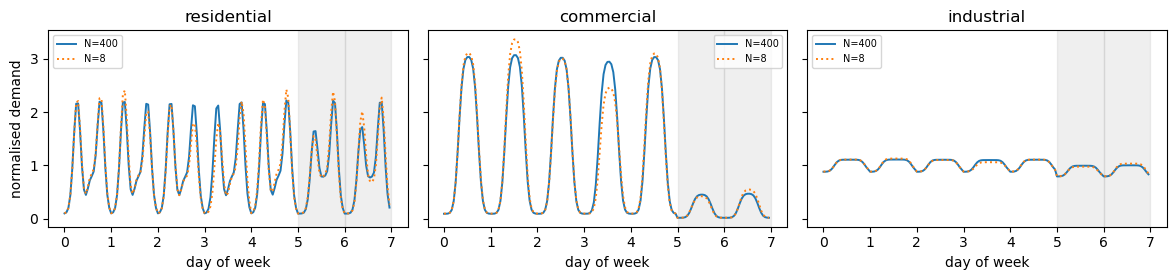

In [3]:
t = np.arange(24) + .5
fig, axes = plt.subplots(1, 3, figsize=(12, 2.9), sharey=True)
for ax, s in zip(axes, le.SECTORS):
    for n, ls in ((400, "-"), (8, ":")):
        wk = np.concatenate([le.sector_day_shape(t, s, n, np.random.default_rng(d),
                                                 d % 7 >= 5, PARAMS["patterns"])
                             for d in range(7)])
        ax.plot(np.arange(len(wk)) / 24, wk / wk.mean(), ls, lw=1.4, label=f"N={n}")
    for d in (5, 6):
        ax.axvspan(d, d + 1, color="grey", alpha=.12, zorder=0)
    ax.set(title=s, xlabel="day of week"); ax.legend(fontsize=7)
axes[0].set_ylabel("normalised demand")
plt.tight_layout(); plt.show()

## 2. Sanity checks

Design invariants, volume bookkeeping, hydraulic consistency, determinism, and the
shape/level orthogonality claim. Everything downstream depends on these.

In [4]:
checks, ref = le.sanity_suite(CTX)

                                                      check  pass                      detail
                                  S1 level ordering R<M<C<I  True   1.00 < 2.12 < 3.43 < 9.21
                                S2 beta=0 is volume-neutral  True            max dev 0.00e+00
        S3 night/day: commercial < residential < industrial  True          0.04 < 0.47 < 0.81
                           S4 commercial closes at weekends  True                  we/wd 0.15
                     S5 crowd smoothing: small N is noisier False           cv 0.671 vs 0.673
                       S6 sector volumes sum to node volume  True        max rel gap 1.43e-16
                      S7 simulated volume matches portfolio  True        max rel err 1.55e-15
                S8 calibration renormalises to anchor total  True                 calib 0.797
      S9 demand-less nodes are exactly the zero-demand ones  True    1 missing, 1 zero-demand
                                        S10 V1 mass balance 

## 3. One world, before / during / after

In [5]:
BASE = [{"tgt_district": "District_D", "to_income": "low", "to_land_use": "commercial"}]
r0 = le.run_world(CTX, "LR_LM_LC_LR_LR", BASE, beta=0.0)    # shape only
r5 = le.run_world(CTX, "LR_LM_LC_LR_LR", BASE, beta=0.5)    # shape + level
print(f"calibration {r0['calibration']:.3f} | "
      f"shape_shift  beta0 {le.shape_shift(r0):.3f}  beta.5 {le.shape_shift(r5):.3f}")

calibration 1.000 | shape_shift  beta0 0.377  beta.5 0.557


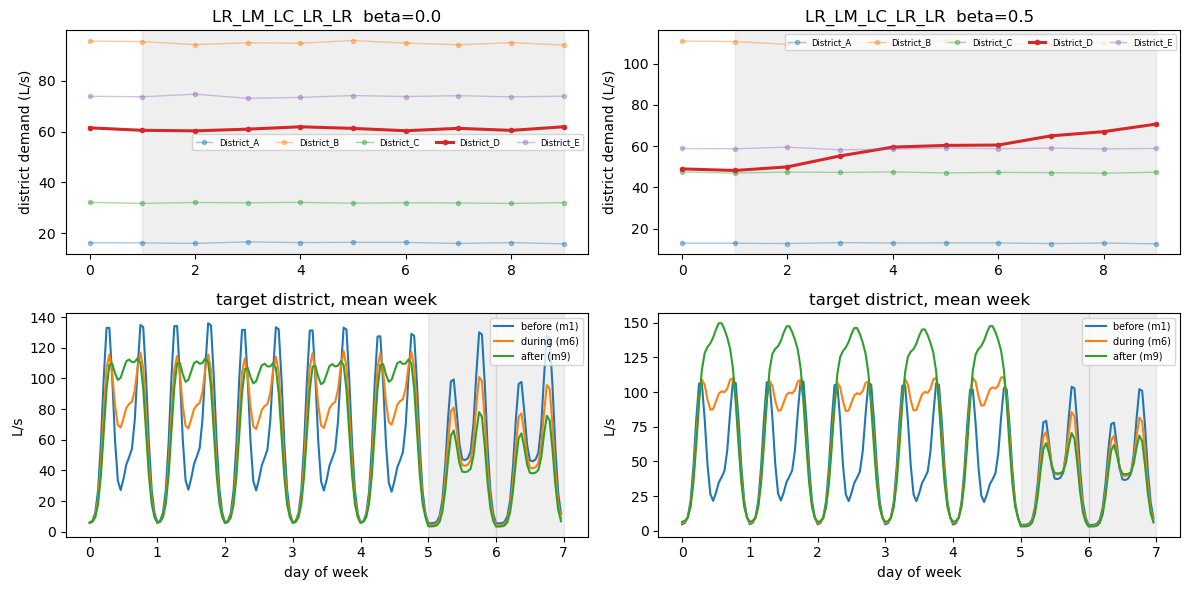

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for col, r in enumerate((r0, r5)):
    ax, m = axes[0, col], r["demand"].groupby("month")[le.dnodes(r)].mean()
    for dist, ns in CTX.districts["districts"].items():
        ns = [n for n in ns if n in m.columns]
        tgt = dist in [d["tgt_district"] for d in r["drifts"]]
        ax.plot(m.index, m[ns].sum(axis=1), marker="o", ms=3, label=dist,
                lw=2.2 if tgt else 1.0, alpha=1.0 if tgt else .4)
    ph = le.phases(r)
    ax.axvspan(ph["before"], ph["after"], color="grey", alpha=.12, zorder=0)
    ax.set(ylabel="district demand (L/s)", title=f"{r['map']}  beta={r['cfg']['beta']}")
    ax.legend(fontsize=6, ncol=5)

    ax, st = axes[1, col], le.steps(r)
    for name, mth in le.phases(r).items():
        ax.plot(np.arange(7 * st) / st, le.week_profile(r, mth), lw=1.5,
                label=f"{name} (m{mth})")
    for d in (5, 6):
        ax.axvspan(d, d + 1, color="grey", alpha=.12, zorder=0)
    ax.set(xlabel="day of week", ylabel="L/s", title="target district, mean week")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

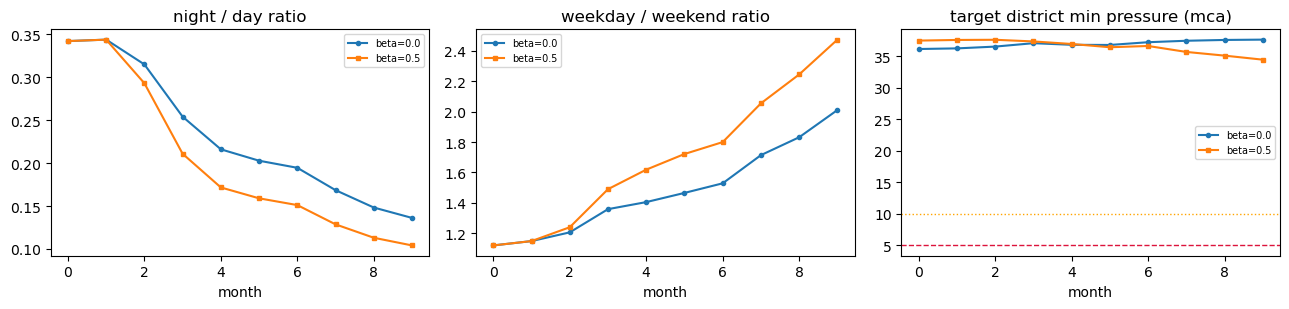

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for r, mk in ((r0, "o"), (r5, "s")):
    ms = range(r["time"]["n_months"])
    nd = [le.night_day(r, m) for m in ms]
    axes[0].plot(ms, [x[0] for x in nd], marker=mk, ms=3, label=f"beta={r['cfg']['beta']}")
    axes[1].plot(ms, [x[1] for x in nd], marker=mk, ms=3, label=f"beta={r['cfg']['beta']}")
    p = r["pressures"].assign(month=r["demand"]["month"].to_numpy())
    axes[2].plot(p.groupby("month")[le.tnodes(r)].min().min(axis=1), marker=mk, ms=3,
                 label=f"beta={r['cfg']['beta']}")
for ax, ttl in zip(axes, ["night / day ratio", "weekday / weekend ratio",
                          "target district min pressure (mca)"]):
    ax.set(xlabel="month", title=ttl); ax.legend(fontsize=7)
axes[2].axhline(le.HARD_FLOOR, color="crimson", ls="--", lw=1)
axes[2].axhline(le.BAND[0], color="orange", ls=":", lw=1)
plt.tight_layout(); plt.show()

## 4. Does the signature survive the scaler?

Per-client MinMax fitted on the reference months is affine, so it cannot remove a
*shape* change. If `shape_shift` is large at `beta=0`, land use is legible with no
level change at all — which is the whole argument for the sector model.

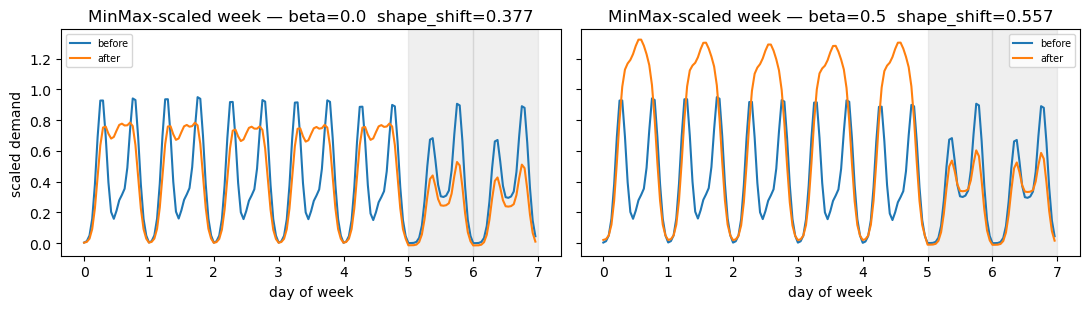

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, r in zip(axes, (r0, r5)):
    ph = le.phases(r)
    a = le.week_profile(r, ph["before"], scaled=True)
    b = le.week_profile(r, ph["after"], scaled=True)
    ax.plot(np.arange(len(a)) / le.steps(r), a, lw=1.5, label="before")
    ax.plot(np.arange(len(b)) / le.steps(r), b, lw=1.5, label="after")
    for d in (5, 6):
        ax.axvspan(d, d + 1, color="grey", alpha=.12, zorder=0)
    ax.set(xlabel="day of week",
           title=f"MinMax-scaled week — beta={r['cfg']['beta']}  "
                 f"shape_shift={le.shape_shift(r):.3f}")
    ax.legend(fontsize=7)
axes[0].set_ylabel("scaled demand")
plt.tight_layout(); plt.show()

## 5. Baselines

Do the initial maps survive with no drift at all? Any map that fails here confounds
every drift result on it, so this runs first and gates the ablation.

In [9]:
GRID = le.default_grid(CTX)                      # widen here: n_random, anchors, to_incomes
base = le.baselines(CTX, GRID)
print(f"{int((~base['passed']).sum())} / {len(base)} baseline runs infeasible")
display(base[~base["passed"]][["map", "beta", "pmin", "pmax", "fail"]].round(1))
base.groupby("beta")[["pmin", "pmax", "peak_lps"]].agg(["min", "max"]).round(1)

0 / 80 baseline runs infeasible


,map,beta,pmin,pmax,fail


pmin        pmax       peak_lps       
       min   max   min   max      min    max
beta                                        
0.00  21.3  41.6  47.2  48.5    396.5  832.1
0.25  21.3  41.6  47.2  48.5    396.5  832.1
0.50  21.3  41.6  47.2  48.5    396.5  832.1
0.75  21.3  41.6  47.2  48.5    396.5  832.1
1.00  21.3  41.6  47.2  48.5    395.7  832.1

## 6. Ablation

Beta ladder over (map, drifting clients, destination land use, income, anchor).
Ascending beta, stop at the first failure. Envelope mode: every target node switches
at the warm-up month and the seasonal peak is pinned to the scored month, so each run
is the fully-drifted worst case rather than a timeline.

20/336  1.7 min  eta 26.7 min
40/336  3.3 min  eta 24.1 min
60/336  4.7 min  eta 21.8 min
80/336  6.4 min  eta 20.4 min
100/336  8.1 min  eta 19.1 min
120/336  9.9 min  eta 17.9 min
140/336  11.8 min  eta 16.6 min
160/336  13.6 min  eta 14.9 min
180/336  15.2 min  eta 13.2 min
200/336  16.9 min  eta 11.5 min
220/336  18.6 min  eta 9.8 min
240/336  20.4 min  eta 8.2 min
260/336  22.4 min  eta 6.6 min
280/336  23.9 min  eta 4.8 min
300/336  25.5 min  eta 3.1 min
320/336  27.2 min  eta 1.4 min
runs 1656 | combos 336 | never pass 0 | always pass 304

failure modes:
fail
V3_floor,V4_band    29
V4_band              3 

beta_max_pass by target land use:
             median   min  count
to_land_use                     
commercial      1.0  0.00    112
industrial      1.0  0.25    112
mixed           1.0  0.50    112 

beta_max_pass by number of drifting clients:
n_targets
1    1.0
2    1.0
5    1.0 

tightest 15:
           map   targets to_land_use to_income  anchor_scale  beta_max_pass  beta

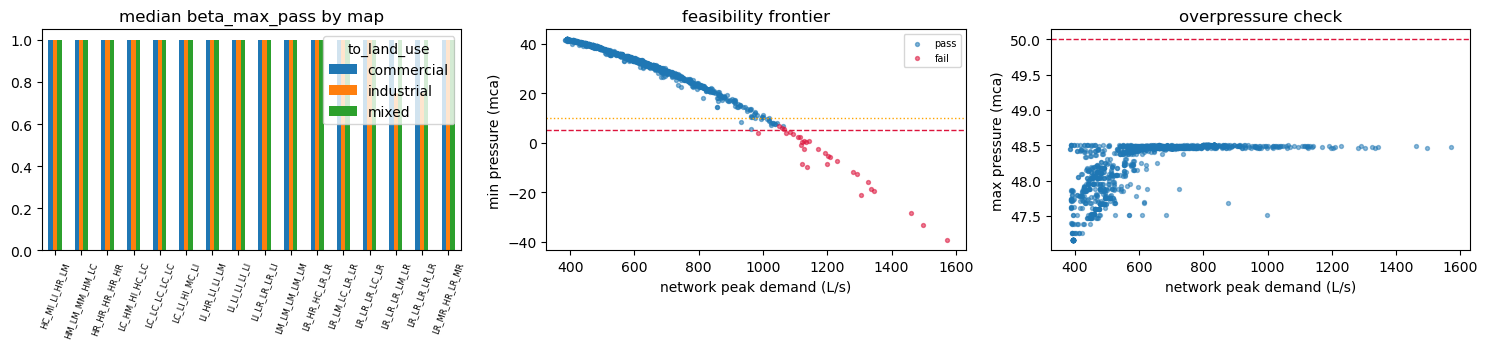

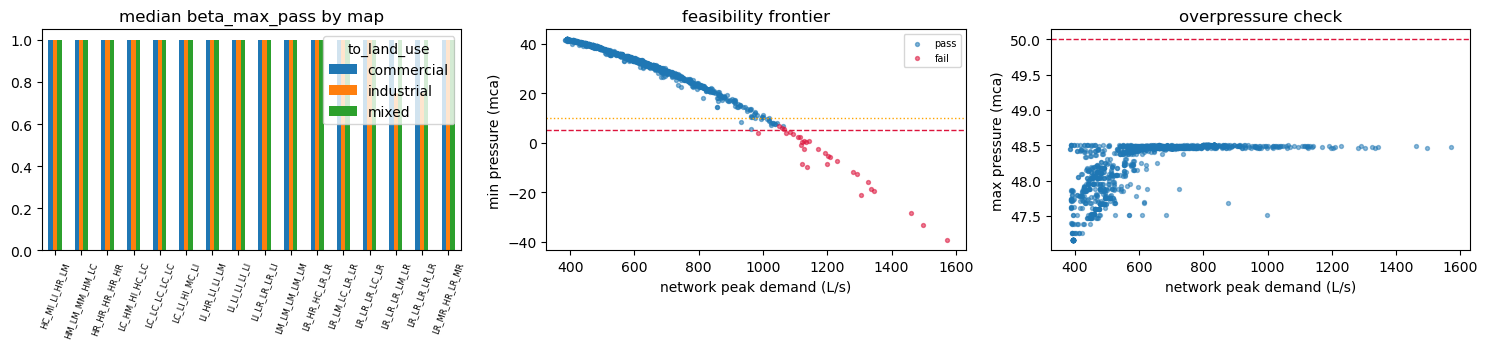

In [10]:
abl = le.ablation(CTX, GRID)                     # ~10-25 min at the default grid
edge = le.report(abl, base=base)
le.plot_report(abl, edge)

In [14]:
below = abl[abl["pmin"] < le.HARD_FLOOR]
print(f"{len(below)} runs below the floor\n")
display(below.groupby(["to_land_use", "beta"]).size().rename("n").to_frame().T)
display(below[["map", "targets", "to_land_use", "beta", "peak_lps", "pmin", "drifted_%"]]
        .sort_values("pmin").head(35).round(1))

29 runs below the floor



to_land_use commercial           industrial           mixed     
beta              0.25 0.50 1.00       0.50 0.75 1.00  0.75 1.00
n                    2    2    4          2    4   13     1    1

,map,targets,to_land_use,beta,peak_lps,pmin,drifted_%
401,LR_LR_LR_LC_LR,A+B+C+D+E,industrial,0.8,1571.1,-39.5,100.0
29,LR_LR_LR_LR_LR,B,industrial,1.0,1497.5,-33.1,100.0
200,LR_LM_LC_LR_LR,A+B+C+D+E,industrial,0.8,1461.6,-28.5,100.0
74,LR_LR_LR_LR_LR,E,industrial,1.0,1304.2,-21.1,100.0
230,LR_LR_LR_LM_LR,B,industrial,1.0,1345.0,-19.7,100.0
89,LR_LR_LR_LR_LR,A+D,industrial,1.0,1334.3,-18.6,100.0
1550,LR_HR_HC_LR_LR,A+B+C+D+E,industrial,1.0,1326.3,-15.8,100.0
330,LR_LR_LR_LC_LR,B,industrial,1.0,1291.3,-12.8,100.0
920,LR_MR_HR_LR_MR,A+B+C+D+E,industrial,0.8,1281.2,-11.8,100.0
275,LR_LR_LR_LM_LR,E,industrial,1.0,1136.9,-9.9,100.0


In [16]:
def district_sensitivity(ctx, base_map, to_land_use="commercial", to_income="low",
                         betas=(0.0, 0.25, 0.5, 0.75, 1.0), skip=(), preset=None):
    """Hold base_map fixed; drift each remaining district alone to to_land_use.
    Isolates WHICH district is riskiest, independent of how many are already converted."""
    preset = preset or le.ENVELOPE
    rows = []
    for d in ctx.names():
        if d in skip:
            continue
        for beta in sorted(betas):
            drifts = [{"tgt_district": d, "to_income": to_income, "to_land_use": to_land_use}]
            row = {"district": d.replace("District_", ""), "beta": beta}
            try:
                row |= le.hydraulic_check(le.run_world(ctx, base_map, drifts,
                                                       preset=preset, beta=beta))
            except Exception as e:
                row |= {"passed": False, "fail": f"EXC:{type(e).__name__}"}
            rows.append(row)
            if not row["passed"]:
                break
    df = pd.DataFrame(rows)
    order = [d.replace("District_", "") for d in ctx.names() if d not in skip]
    edge = (df[df.passed].groupby("district")["beta"].max()
            .rename("beta_max_pass").reindex(order))
    margin = (df[df.beta == min(betas)].set_index("district")["pmin"]
              .rename("pmin_at_min_beta").reindex(order))
    return df, pd.concat([edge, margin], axis=1).sort_values("beta_max_pass")


_, rank_bare = district_sensitivity(CTX, "LR_LR_LR_LR_LR", skip=())
_, rank_with_D = district_sensitivity(CTX, "LR_LR_LR_LC_LR", skip=("District_D",))
pd.concat([rank_bare.add_suffix("_bare"), rank_with_D.add_suffix("_with_D")], axis=1)

,beta_max_pass_bare,pmin_at_min_beta_bare,beta_max_pass_with_D,pmin_at_min_beta_with_D
district,,,,
B,0.75,29.991417,0.75,33.663948
A,1.00,28.602177,1.00,32.398853
C,1.00,28.731276,1.00,32.515526
D,1.00,29.854109,NaN,NaN
E,1.00,30.259052,0.75,33.886181


In [18]:
import networkx as nx
import copy

def source_distance(ctx):
    wn = le.configure_network(copy.deepcopy(ctx.wn_raw), ctx.params["hydraulics"],
                              {"n_months": 1, "days_per_month": 7, "resolution_h": 1})
    G = wn.to_graph().to_undirected()
    sources = wn.reservoir_name_list + wn.tank_name_list
    return {d: min(nx.shortest_path_length(G, s, n) for s in sources
                   for n in ctx.districts["districts"][d] if n in G)
           for d in ctx.districts["districts"]}

dist = pd.Series(source_distance(CTX)).rename("hops_from_source")
rank_bare.join(dist.rename(index=lambda d: d.replace("District_", "")))

,beta_max_pass,pmin_at_min_beta,hops_from_source
district,,,
B,0.75,29.991417,2
A,1.00,28.602177,1
C,1.00,28.731276,2
D,1.00,29.854109,3
E,1.00,30.259052,8


In [19]:
_, rank_fine = district_sensitivity(CTX, "LR_LR_LR_LC_LR", skip=("District_D",),
                                    betas=np.linspace(0, 1, 11))
rank_fine

,beta_max_pass,pmin_at_min_beta
district,,
B,0.8,33.663948
E,0.9,33.886181
A,1.0,32.398853
C,1.0,32.515526


In [20]:
from scipy.special import erf
import scipy
print(scipy.__version__, erf(1.0))

1.15.2 0.8427007929497148


## 7. Read-out

Fill in from the run above:

- **Capacity.** Where does `pmin` cross 5 mca on the frontier plot? That peak-demand
  figure is the network's budget and every other decision sits under it.
- **`beta_max_pass` by land use.** Industrial should break first, then commercial,
  then mixed. If they are equal, something upstream is short-circuiting the ladder.
- **`beta_max_pass` by client count.** Should fall as more districts drift together.
- **Overpressure.** Max pressure has stayed below 50 mca in every run so far; the
  band's upper edge is not the binding constraint here.
- **The trade.** `shape_shift` at `beta=0` is the scaler-invariant signal with zero
  volume change and zero hydraulic risk. The level effect is what threatens
  feasibility and is *not* what carries the regime information — so a low beta buys
  most of the legibility at almost none of the risk.